# Salary Range Prediction

This Markdown document provides a comprehensive overview of the NYC Job Salary Range Prediction project,Data Preparation, Model Building, and Evaluation,Visualization. The project leverages a dataset of New York City job postings to build a multi-output regression model that predicts salary ranges (minimum and maximum) based on job attributes like agency, title, location, and qualifications. Developed using Python, scikit-learn, XGBoost, and category_encoders, the project follows best practices for reproducible ML workflows, addressing challenges like high-cardinality categoricals, multi-target prediction, and pipeline compatibility.

**Project Benefits:**

- Enhanced Recruitment Process: By accurately predicting salary ranges, recruiters can better align job postings with market standards, attracting top-tier talent while optimizing hiring costs.
- Improved Candidate Experience: Providing transparent salary expectations upfront can significantly enhance candidate engagement and satisfaction, leading to higher acceptance rates.
- Strategic Decision-Making: Access to reliable salary forecasts empowers HR professionals and organizational leaders to make informed decisions regarding budget allocation and resource planning.

**Key Objectives:**

- Predict dual continuous targets: 'Salary Range From' (min, e.g., $15–$100k) and 'Salary Range To' (max, e.g., $50k–$208k) using multi-output regression.

- Handle data imbalances (e.g., career levels), outliers (log-transform), and leakage (early train/test split).

- Achieve >89% R² accuracy on historical data for practical utility.

- Deploy a robust, interpretable system for end-to-end predictions, with visuals for stakeholder.

  
**Dataset Note:** Load the full dataset CSV (expected: 'NYC_Jobs_Full.csv' or similar; adjust path as needed). The attached extract is used for testing, but run on the complete 5120-row file.


In [58]:
# Import libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
from scipy.stats import skew, kurtosis
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer,OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import category_encoders as ce  
from datetime import datetime
import joblib

import warnings
warnings.filterwarnings('ignore')
# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [59]:
# Load the dataset
df = pd.read_csv('Jobs_NYC_Postings.csv')  

In [60]:
# Basic structure check
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (5120, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5120 entries, 0 to 5119
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Job ID                         5120 non-null   int64  
 1   Agency                         5120 non-null   object 
 2   Posting Type                   5120 non-null   object 
 3   # Of Positions                 5120 non-null   int64  
 4   Business Title                 5120 non-null   object 
 5   Civil Service Title            5120 non-null   object 
 6   Title Classification           5120 non-null   object 
 7   Title Code No                  5120 non-null   object 
 8   Level                          5120 non-null   object 
 9   Job Category                   5120 non-null   object 
 10  Full-Time/Part-Time indicator  5003 non-null   object 
 11  Career Level                   5120 non-null   object 
 12  Salary Range From     

,Job ID,# Of Positions,Salary Range From,Salary Range To,Recruitment Contact
count,5120.000000,5120.000000,5120.000000,5120.000000,0.0
mean,598721.366211,2.070898,64625.224123,89978.575734,NaN
std,28274.636161,5.799227,31378.516179,46732.299939,NaN
min,469953.000000,1.000000,0.000000,15.000000,NaN
25%,586358.000000,1.000000,51869.000000,64608.000000,NaN
50%,607060.000000,1.000000,62397.000000,85147.000000,NaN
75%,621404.000000,1.000000,80557.000000,113550.000000,NaN
max,628806.000000,150.000000,225000.000000,252165.000000,NaN


In [61]:
temp = pd.DataFrame(index = df.columns)
temp['data_type'] = df.dtypes
temp['null_count'] = df.isnull().sum()
temp['unique_count'] = df.nunique()
temp

,data_type,null_count,unique_count
Job ID,int64,0,2626
Agency,object,0,59
Posting Type,object,0,2
# Of Positions,int64,0,35
Business Title,object,0,1781
Civil Service Title,object,0,365
Title Classification,object,0,5
Title Code No,object,0,388
Level,object,0,18
Job Category,object,0,183


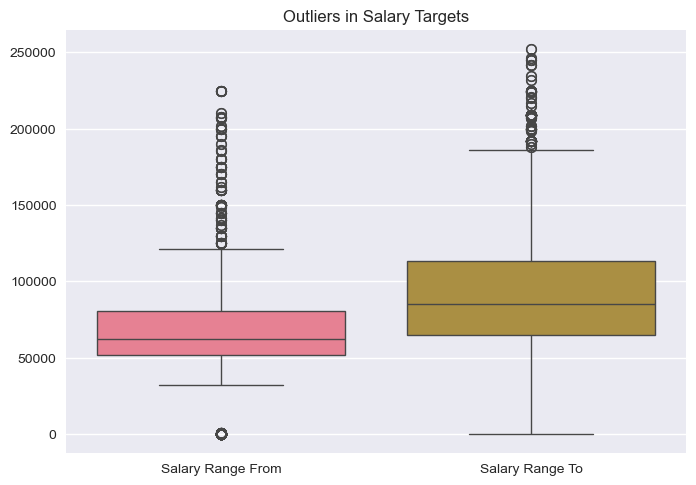

In [62]:
# Outliers already visualized in box plots; refine for targets if needed
sns.boxplot(data=df[['Salary Range From', 'Salary Range To']])
plt.title('Outliers in Salary Targets')
plt.show()

## Skewness and Kurtosis Checks

Quantify distribution shapes for numerical features, focusing on targets. High skewness (>1 or <-1) suggests transformations; kurtosis measures tail heaviness.


Skewness Values:
 Job ID                 -1.267088
# Of Positions         13.703148
Salary Range From       0.586205
Salary Range To         0.372999
Recruitment Contact          NaN
dtype: float64

Kurtosis Values:
 Job ID                   1.172921
# Of Positions         250.875532
Salary Range From        3.579750
Salary Range To          0.604459
Recruitment Contact           NaN
dtype: float64


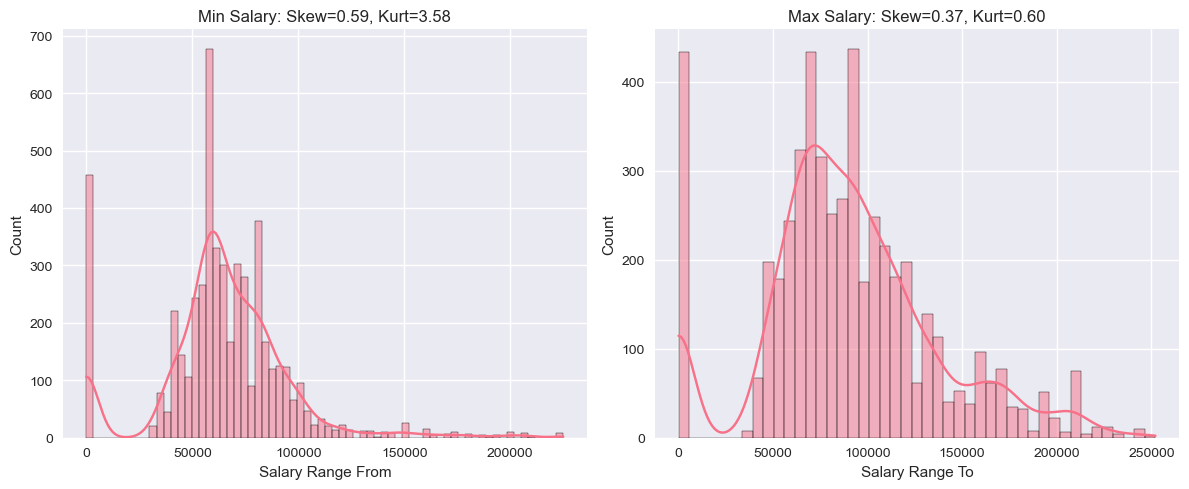

In [63]:
# Skewness and kurtosis for numerical columns (drop NaNs)
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
skew_vals = df[numerical_cols].apply(lambda x: skew(x.dropna()))
kurt_vals = df[numerical_cols].apply(lambda x: kurtosis(x.dropna()))

print("Skewness Values:\n", skew_vals)
print("\nKurtosis Values:\n", kurt_vals)

# Visualize for targets
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df['Salary Range From'].dropna(), kde=True, ax=axes[0])
axes[0].set_title(f'Min Salary: Skew={skew_vals["Salary Range From"]:.2f}, Kurt={kurt_vals["Salary Range From"]:.2f}')
sns.histplot(df['Salary Range To'].dropna(), kde=True, ax=axes[1])
axes[1].set_title(f'Max Salary: Skew={skew_vals["Salary Range To"]:.2f}, Kurt={kurt_vals["Salary Range To"]:.2f}')
plt.tight_layout()
plt.show()

## EDA: Initial Loading and Structure Confirmation

- Loaded the dataset and confirmed shape (expected: 5120 rows, 30 columns based on description).
- `df.info()` provides data types and non-null counts.
- `df.describe()` gives summary statistics for numerical columns (e.g., 'Salary Range From', 'Salary Range To').

This step verifies the data integrity before diving into analysis. Next, we visualize basic distributions via histograms and box plots for numerical features.


Numerical Columns: ['Job ID', '# Of Positions', 'Salary Range From', 'Salary Range To', 'Recruitment Contact']


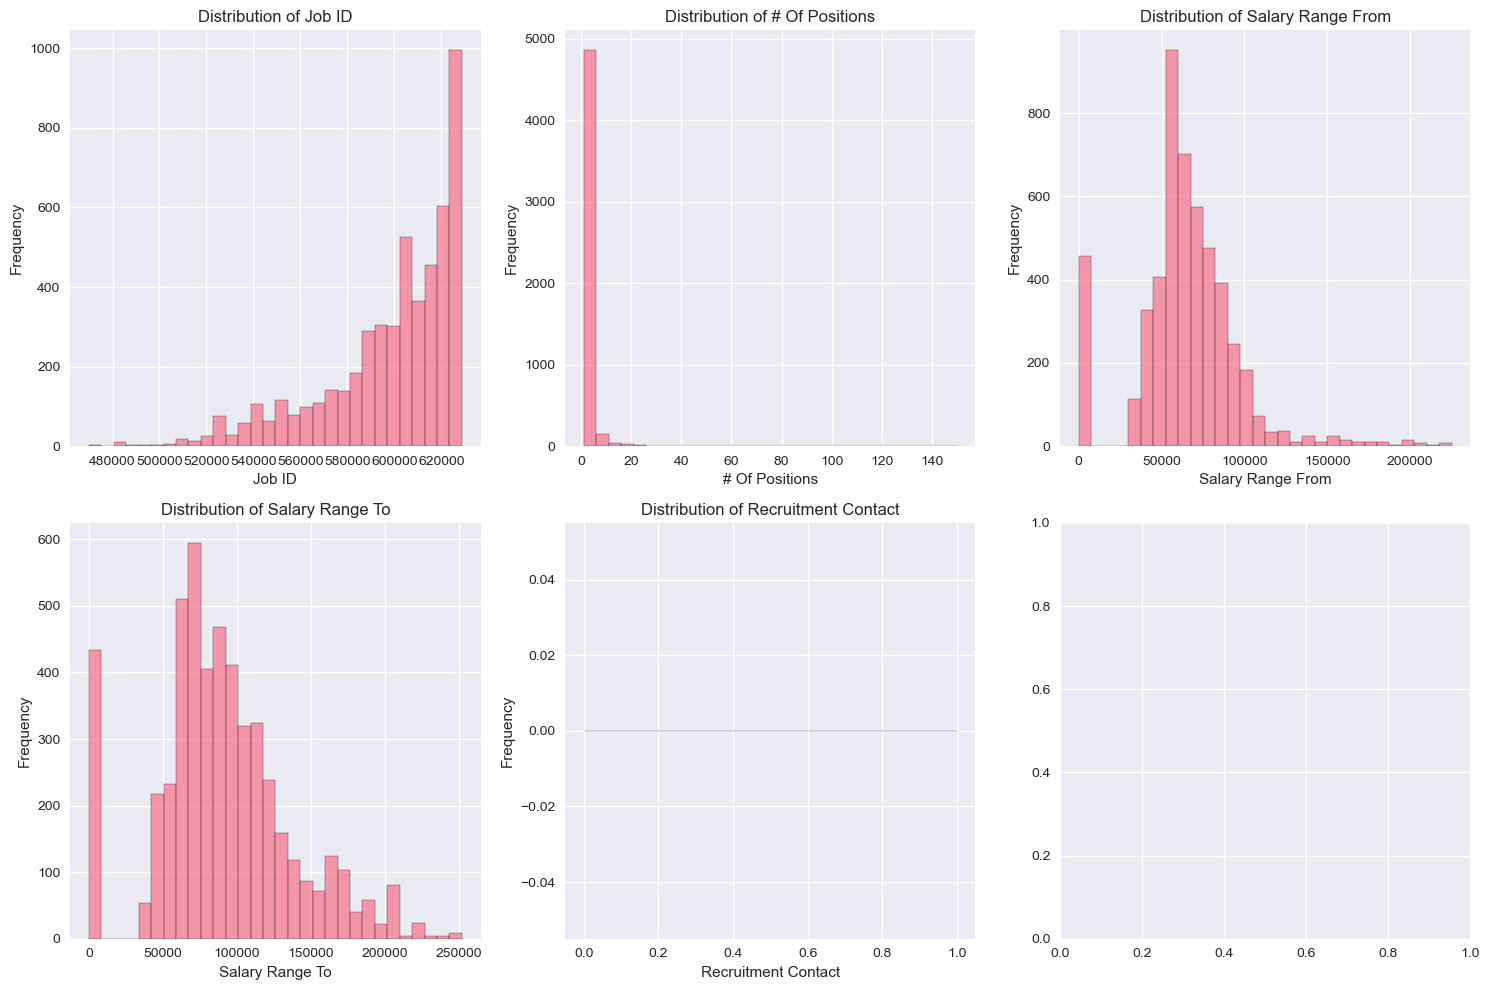

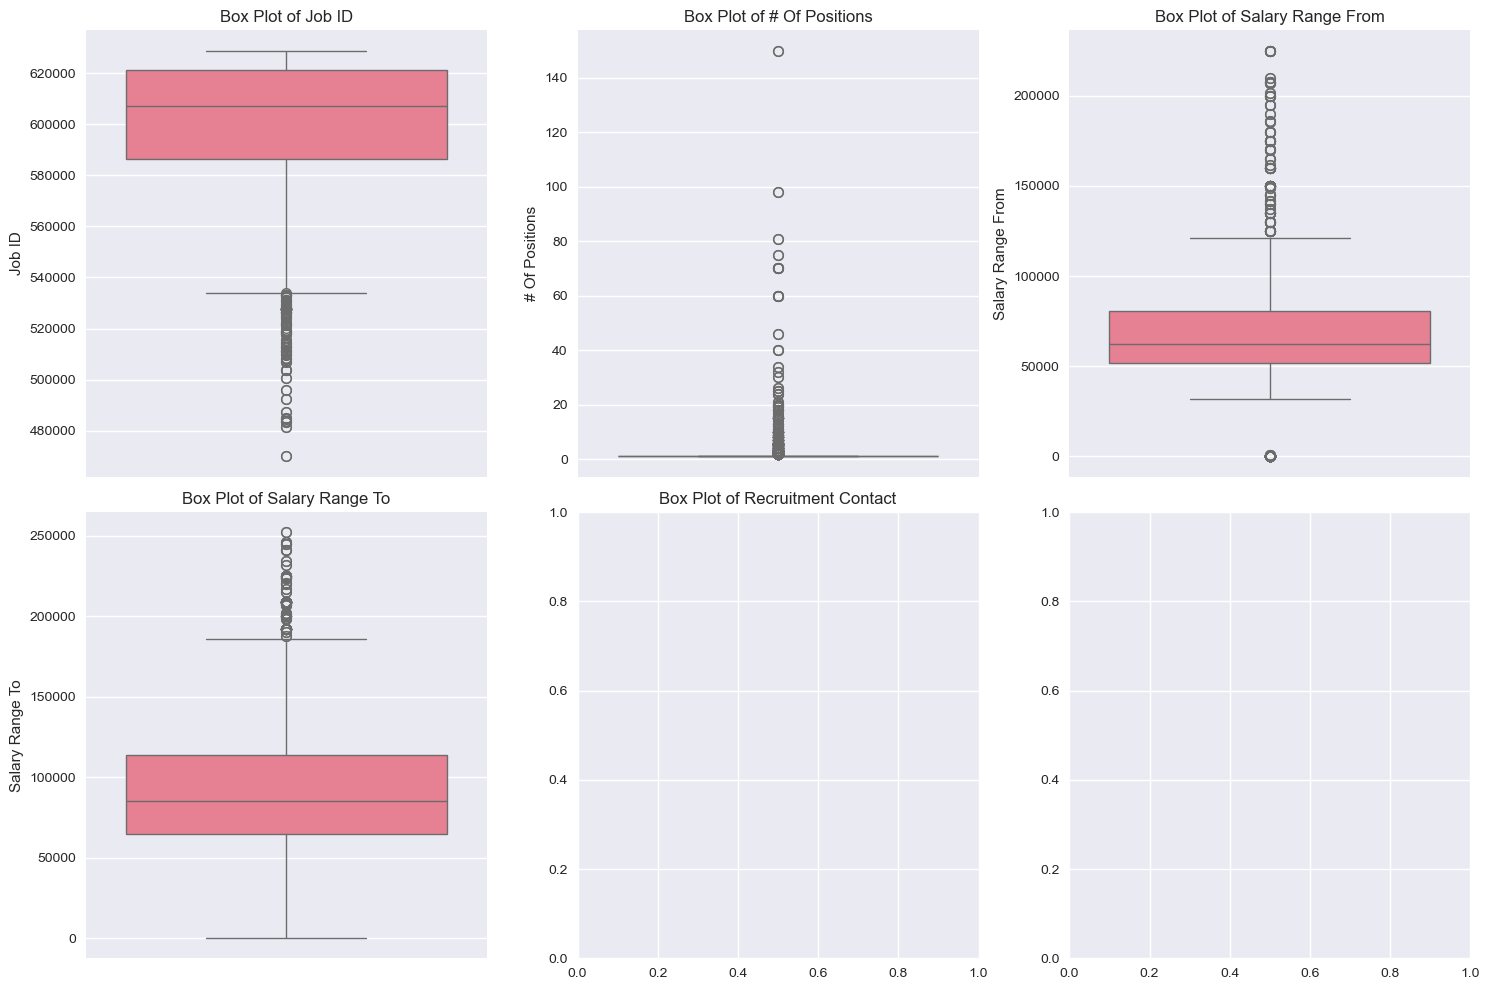

In [64]:
# Identify numerical columns for visualizations
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical Columns:", numerical_cols)

# Histograms for all numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        axes[idx].hist(df[col].dropna(), bins=30, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'Distribution of {col}')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Box plots for all numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    if idx < len(axes):
        sns.boxplot(y=df[col].dropna(), ax=axes[idx])
        axes[idx].set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

## Univariate Analysis

This section focuses on individual feature distributions:
1. Specific focus on target variables: 'Salary Range From' (minimum salary) and 'Salary Range To' (maximum salary).
2. Dedicated histograms for salary columns to inspect target shapes.

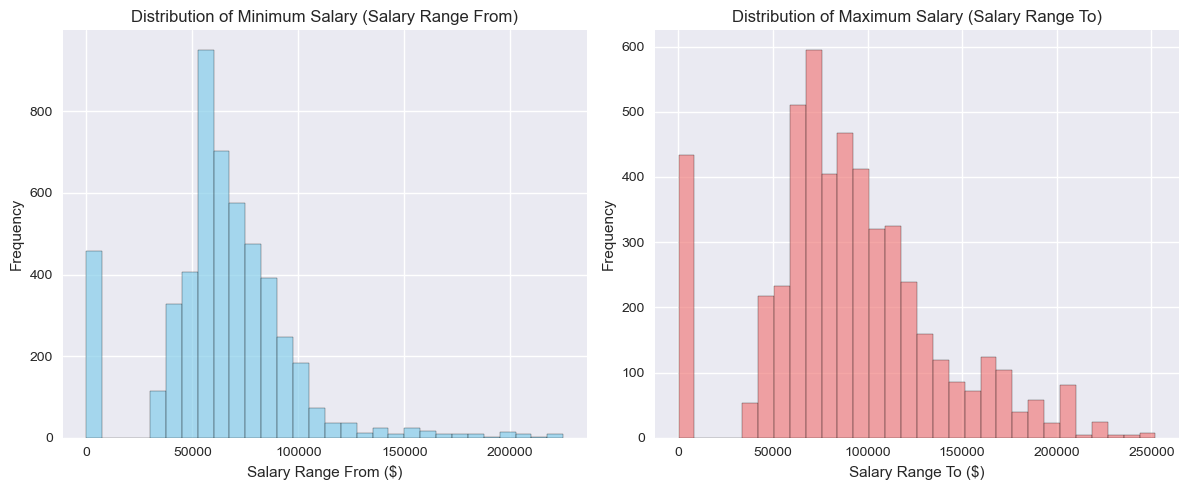

Target Variable Stats:
       Salary Range From  Salary Range To
count        5120.000000      5120.000000
mean        64625.224123     89978.575734
std         31378.516179     46732.299939
min             0.000000        15.000000
25%         51869.000000     64608.000000
50%         62397.000000     85147.000000
75%         80557.000000    113550.000000
max        225000.000000    252165.000000


In [65]:
# Distribution of target variables (min and max salary) with histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Histogram for Salary Range From
axes[0].hist(df['Salary Range From'].dropna(), bins=30, alpha=0.7, edgecolor='black', color='skyblue')
axes[0].set_title('Distribution of Minimum Salary (Salary Range From)')
axes[0].set_xlabel('Salary Range From ($)')
axes[0].set_ylabel('Frequency')

# Histogram for Salary Range To
axes[1].hist(df['Salary Range To'].dropna(), bins=30, alpha=0.7, edgecolor='black', color='lightcoral')
axes[1].set_title('Distribution of Maximum Salary (Salary Range To)')
axes[1].set_xlabel('Salary Range To ($)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Additional univariate for targets: summary stats
print("Target Variable Stats:")
print(df[['Salary Range From', 'Salary Range To']].describe())

## Bivariate Analysis

This explores relationships between features and targets:
1. Relationships between features and targets (via scatter/box plots where applicable).
2. Correlation matrix for numerical columns.
3. Top 5 business titles by count.
4. Bar chart for top 5 business titles.
5. Pair plots for targets against first 5 categorical variables (e.g., 'Agency', 'Posting Type', etc.).

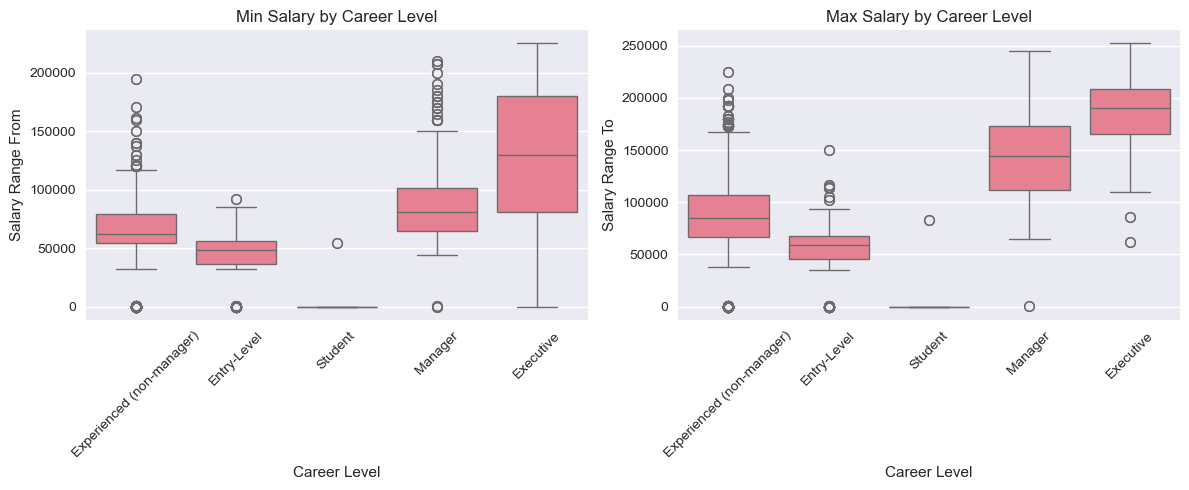

In [66]:
# 1. Sample relationships: Box plots of targets by a key categorical 
if 'Career Level' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.boxplot(data=df, x='Career Level', y='Salary Range From', ax=axes[0])
    axes[0].set_title('Min Salary by Career Level')
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.boxplot(data=df, x='Career Level', y='Salary Range To', ax=axes[1])
    axes[1].set_title('Max Salary by Career Level')
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

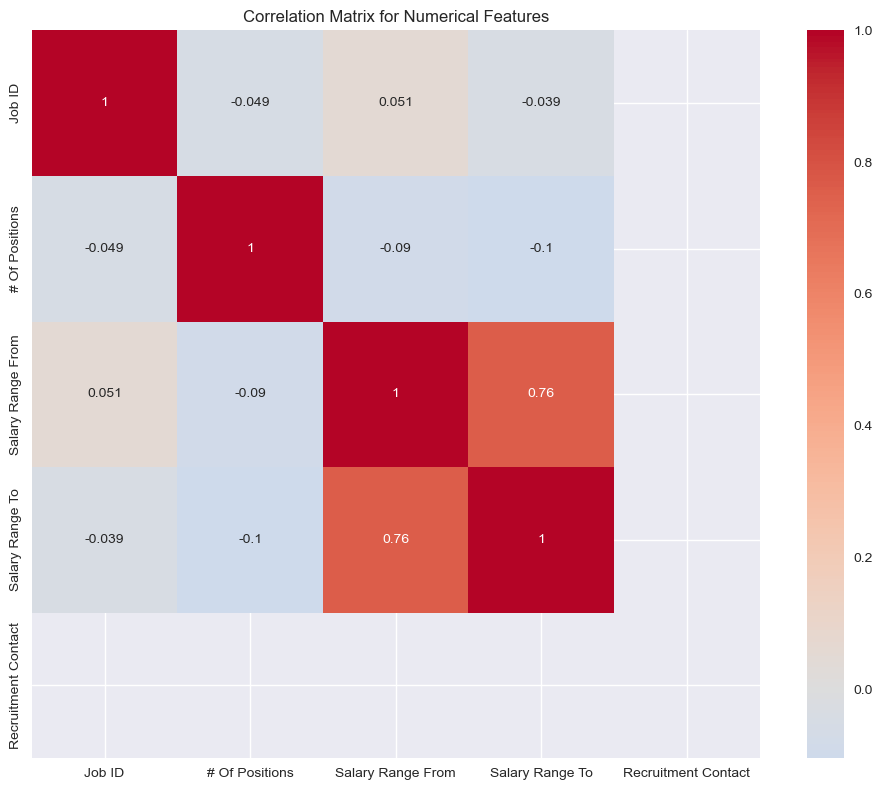

Correlation Matrix Summary:
                        Job ID  # Of Positions  Salary Range From  \
Job ID               1.000000       -0.048522           0.051190   
# Of Positions      -0.048522        1.000000          -0.089609   
Salary Range From    0.051190       -0.089609           1.000000   
Salary Range To     -0.038932       -0.104852           0.761523   
Recruitment Contact       NaN             NaN                NaN   

                     Salary Range To  Recruitment Contact  
Job ID                     -0.038932                  NaN  
# Of Positions             -0.104852                  NaN  
Salary Range From           0.761523                  NaN  
Salary Range To             1.000000                  NaN  
Recruitment Contact              NaN                  NaN  


In [67]:
# Correlation matrix for numerical columns
corr_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, square=True)
plt.title('Correlation Matrix for Numerical Features')
plt.tight_layout()
plt.show()
print("Correlation Matrix Summary:\n", corr_matrix)

Top 5 Business Titles:
 Business Title
Project Manager                63
CASE MANAGEMENT SUPERVISOR     62
ACCOUNTABLE MANAGER            58
Deputy Director                38
CASE MANAGEMENT TEAM LEADER    36
Name: count, dtype: int64


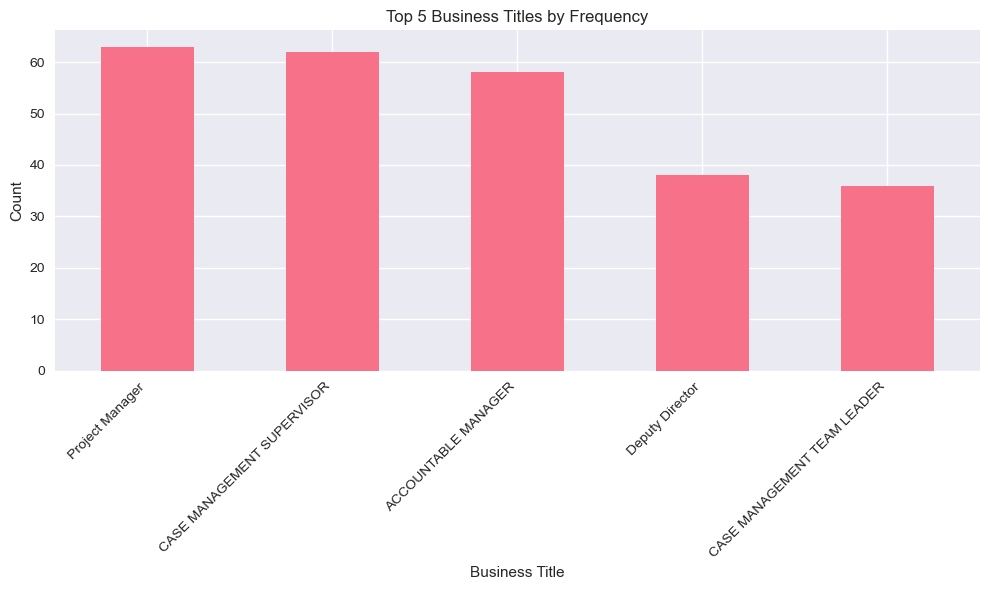

In [68]:
# Top 5 business titles
top_5_titles = df['Business Title'].value_counts().head(5)
print("Top 5 Business Titles:\n", top_5_titles)

# Bar chart
top_5_titles.plot(kind='bar', figsize=(10, 6))
plt.title('Top 5 Business Titles by Frequency')
plt.xlabel('Business Title')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

First 5 Categorical Columns: ['Agency', 'Posting Type', 'Business Title', 'Civil Service Title', 'Title Classification']


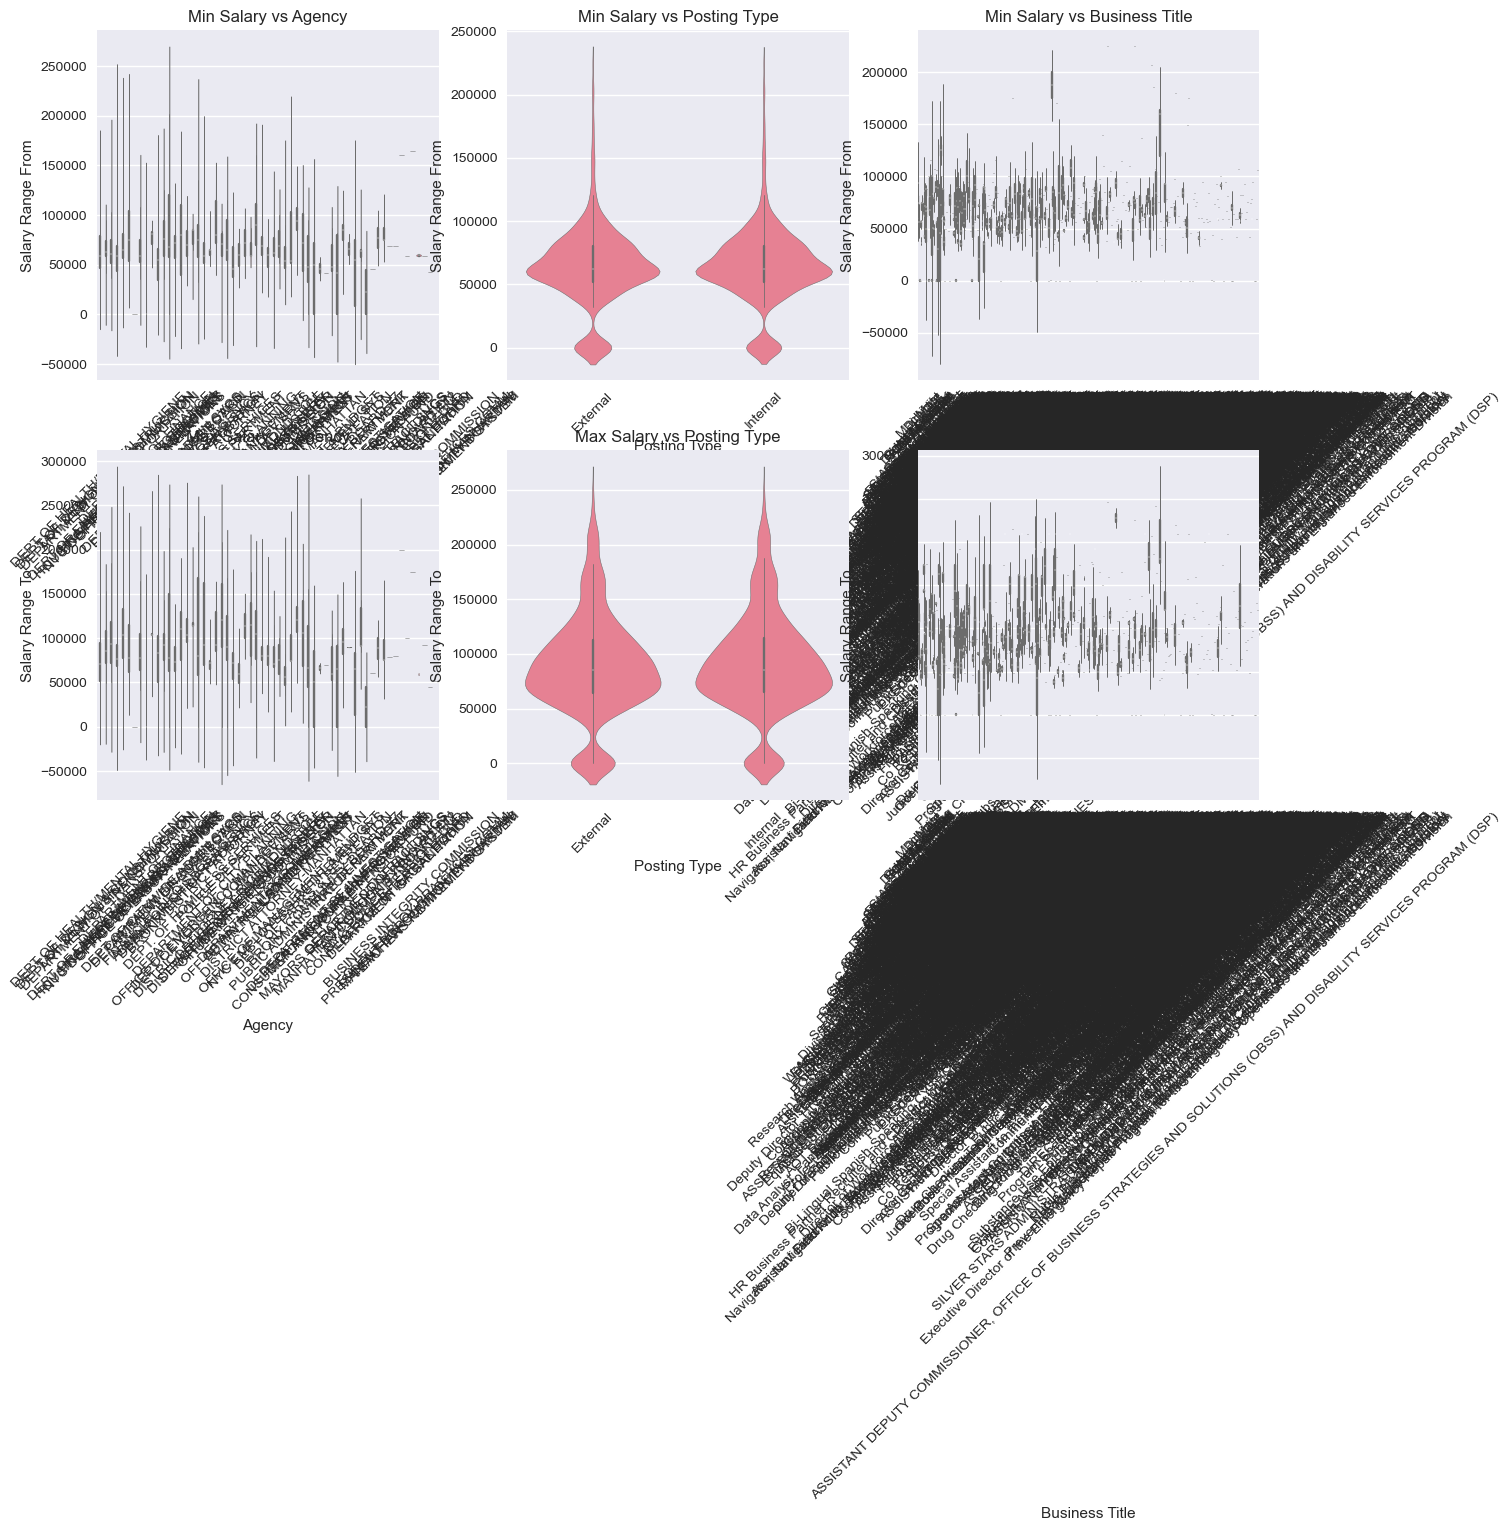

In [69]:
# Pair plots for Min/Max Salary vs. first 5 categorical variables

# First 5 categoricals: Identify them (non-numeric, non-ID)
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()[:5]  # e.g., Agency, Posting Type, etc.
print("First 5 Categorical Columns:", categorical_cols)

# Prepare data for pairplot 
pair_data = df[['Salary Range From', 'Salary Range To'] + categorical_cols[:3]].dropna()  # Limit to 3 cats for plot clarity
fig, axes = plt.subplots(2, len(categorical_cols[:3]), figsize=(15, 10))
for i, col in enumerate(categorical_cols[:3]):
    sns.violinplot(data=df, x=col, y='Salary Range From', ax=axes[0, i])
    axes[0, i].set_title(f'Min Salary vs {col}')
    axes[0, i].tick_params(axis='x', rotation=45)
    
    sns.violinplot(data=df, x=col, y='Salary Range To', ax=axes[1, i])
    axes[1, i].set_title(f'Max Salary vs {col}')
    axes[1, i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Categorical Variables Examination.

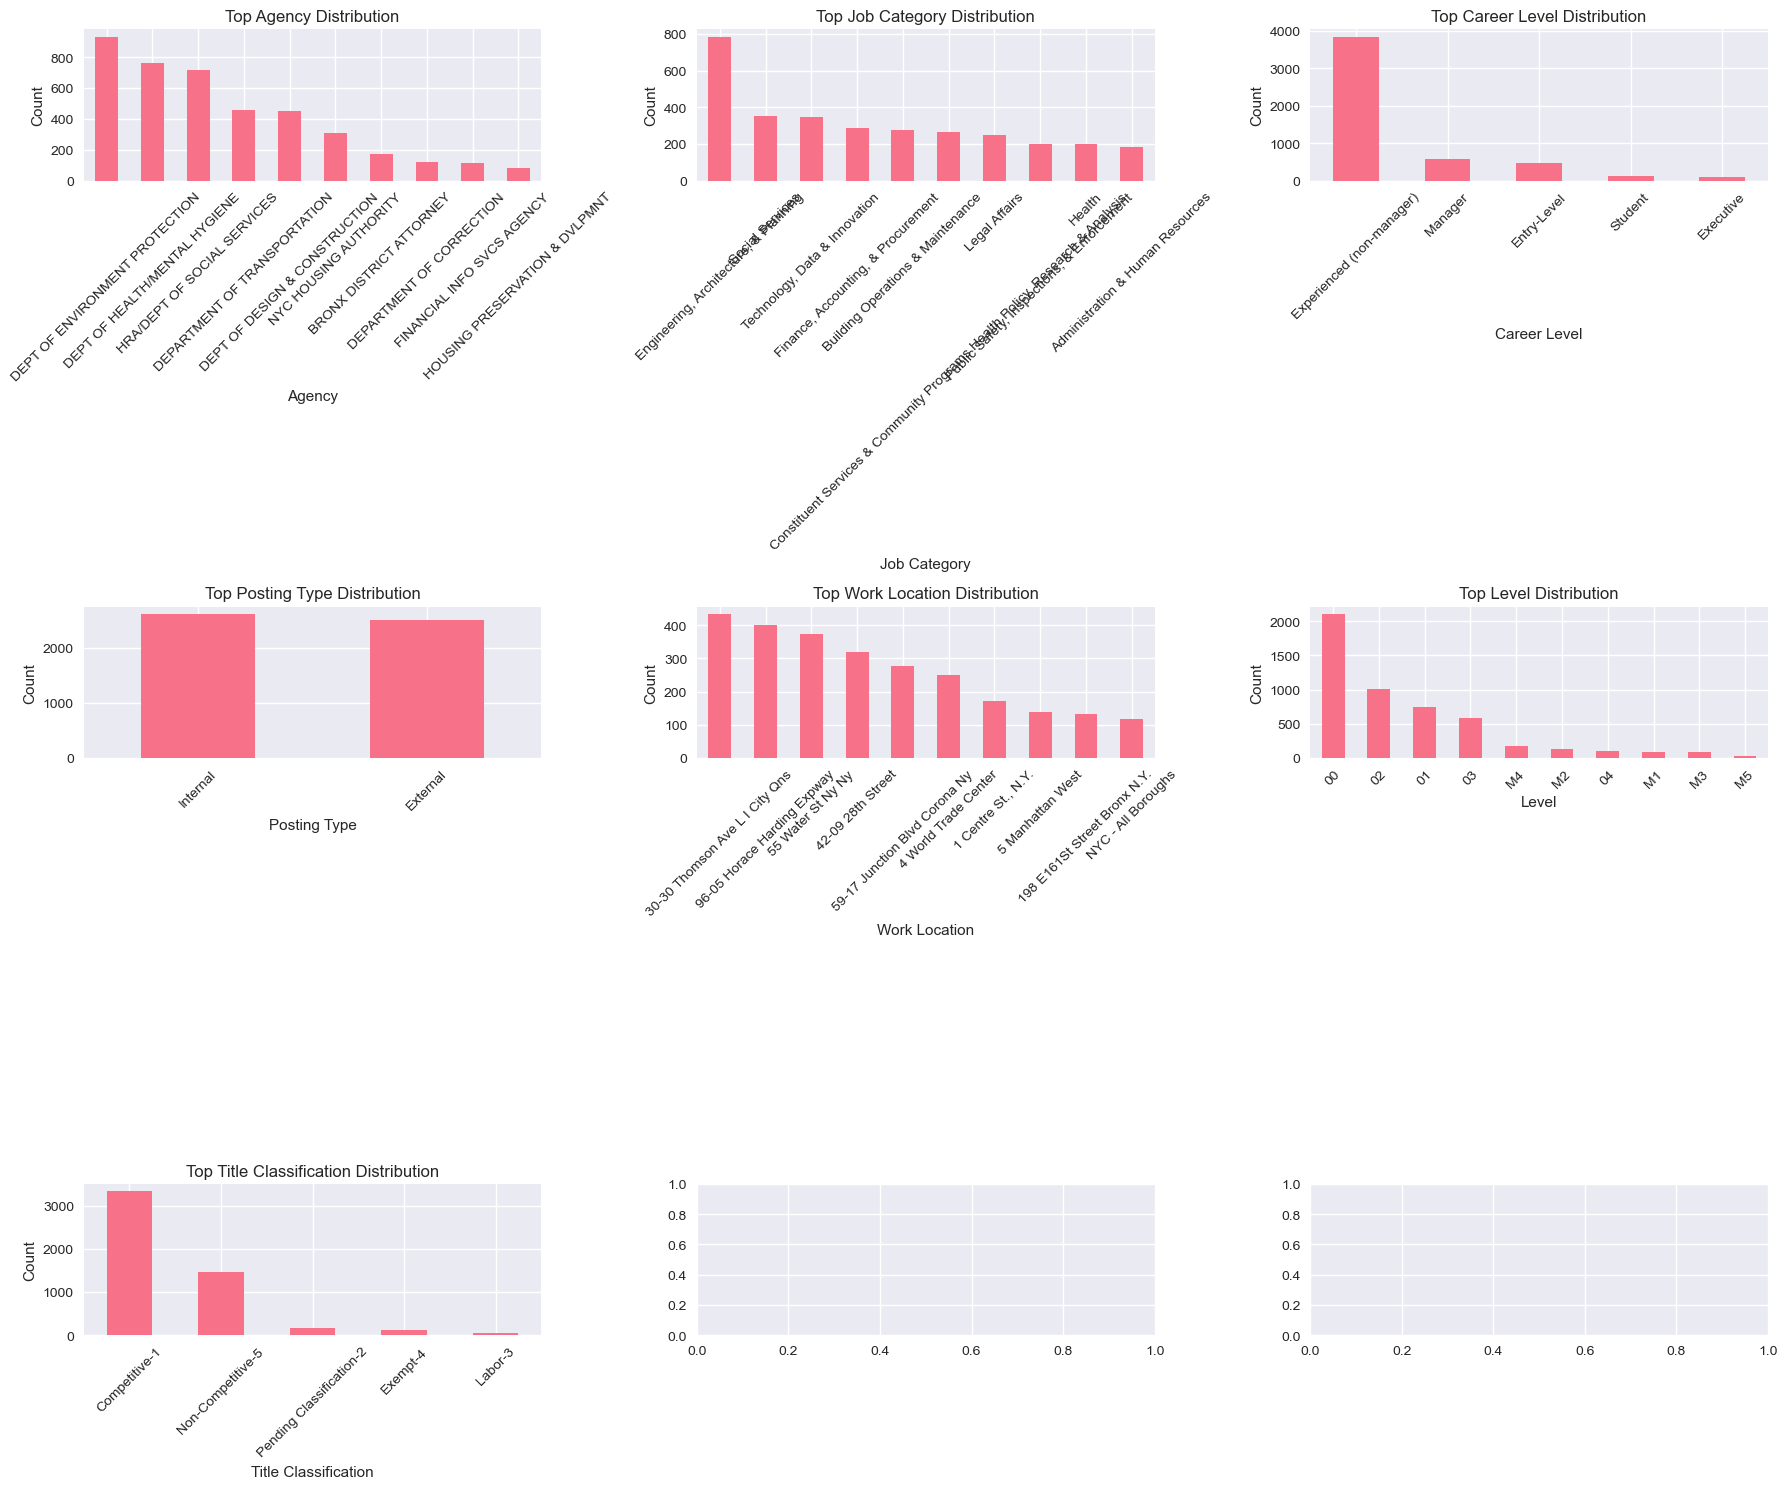

Average Salaries by Career Level:
                            Salary Range From  Salary Range To
Career Level                                                 
Entry-Level                     43262.190902     54217.788504
Executive                      130873.183673    186613.469388
Experienced (non-manager)       63830.021944     86505.900531
Manager                         90137.828904    145033.996712
Student                           826.385075      1260.396269


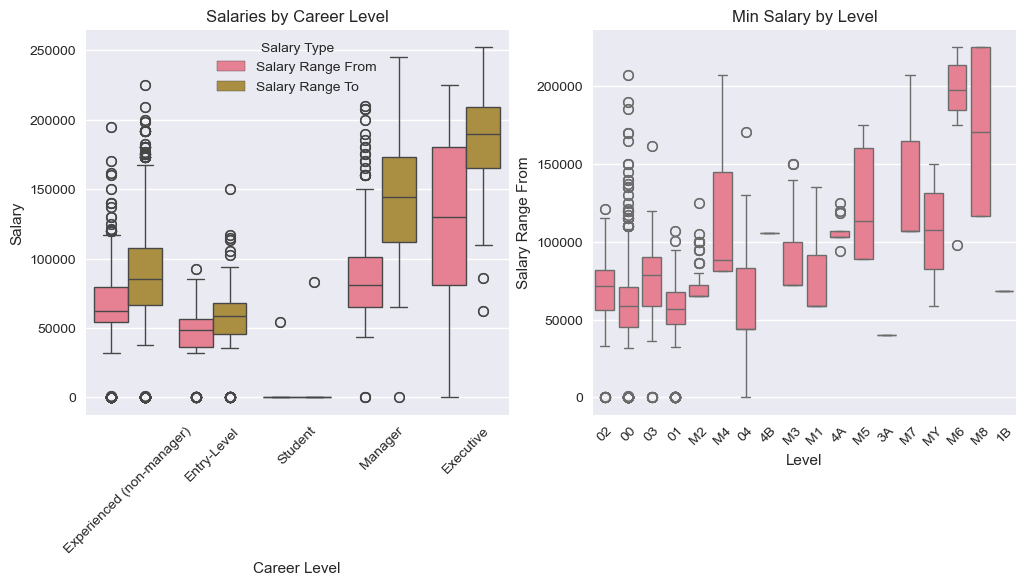

In [70]:
# Key categorical columns
key_cats = ['Agency', 'Job Category', 'Career Level', 'Posting Type', 'Work Location', 'Level', 'Title Classification']

# Value counts and bar charts for each
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

for idx, col in enumerate(key_cats):
    if idx < len(axes) and col in df.columns:
        top_counts = df[col].value_counts().head(10)  # Top 10 for readability
        top_counts.plot(kind='bar', ax=axes[idx])
        axes[idx].set_title(f'Top {col} Distribution')
        axes[idx].set_xlabel(col)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Cross-tab example: Salary by 'Career Level' (grouped box plot)
if 'Career Level' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    df_melted = pd.melt(df, id_vars=['Career Level'], value_vars=['Salary Range From', 'Salary Range To'],
                        var_name='Salary Type', value_name='Salary')
    sns.boxplot(data=df_melted, x='Career Level', y='Salary', hue='Salary Type', ax=axes[0])
    axes[0].set_title('Salaries by Career Level')
    axes[0].tick_params(axis='x', rotation=45)
    
    # Cross-tab summary
    cross_tab = df.groupby('Career Level')[['Salary Range From', 'Salary Range To']].mean()
    print("Average Salaries by Career Level:\n", cross_tab)

# Similar for 'Level' or 'Title Classification'
if 'Level' in df.columns:
    sns.boxplot(data=df, x='Level', y='Salary Range From')
    plt.title('Min Salary by Level')
    plt.xticks(rotation=45)
    plt.show()

## Missing Values Handling

- 'Recruitment Contact': 100% null → Drop.
- 'Hours/Shift', 'Work Location 1': >60% missing → Impute/drop based on relevance (e.g., drop if not predictive).
- 'Preferred Skills' (24% missing), 'Additional Information' (36%) → Fill with 'Unknown'.
- Analyze impact (e.g., % missing per row).

In [71]:
# Missing values summary
missing_summary = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_summary, 'Missing %': missing_pct})
print("Missing Values Summary:\n", missing_df)

# Drop 'Recruitment Contact'
df.drop('Recruitment Contact', axis=1, inplace=True)
print("\nDropped 'Recruitment Contact'.")

# Impute selected text columns with 'Unknown'
text_cols_to_impute = ['Preferred Skills', 'Additional Information', 'Hours/Shift']
for col in text_cols_to_impute:
    if col in df.columns:
        df[col] = df[col].fillna('Unknown')

# For high-missing like 'Work Location 1' (>60%), consider drop
if 'Work Location 1' in df.columns and (df['Work Location 1'].isnull().sum() / len(df)) > 0.6:
    df.drop('Work Location 1', axis=1, inplace=True)
    print("Dropped 'Work Location 1' due to >60% missing.")

# Check post-handling
print("Updated Shape:", df.shape)
print("Remaining Missing:\n", df.isnull().sum().sum())

Missing Values Summary:
                                Missing Count   Missing %
# Of Positions                             0    0.000000
Additional Information                  1862   36.367188
Agency                                     0    0.000000
Business Title                             0    0.000000
Career Level                               0    0.000000
Civil Service Title                        0    0.000000
Division/Work Unit                         0    0.000000
Full-Time/Part-Time indicator            117    2.285156
Hours/Shift                             3210   62.695312
Job Category                               0    0.000000
Job Description                            0    0.000000
Job ID                                     0    0.000000
Level                                      0    0.000000
Minimum Qual Requirements                 43    0.839844
Post Until                              3616   70.625000
Posting Date                               0    0.000000
Postin

## Date Columns Conversion and Feature Derivation

Convert 'Posting Date', 'Post Until', 'Posting Updated' to datetime.

New Date Features Summary:
       Posting Duration (Days)  Posting Age (Days)
count              5120.000000         5120.000000
mean                 42.598242          785.327344
std                 111.925483          188.981118
min                   0.000000          589.000000
25%                   0.000000          635.750000
50%                   0.000000          735.000000
75%                  30.000000          866.000000
max                 999.000000         1932.000000


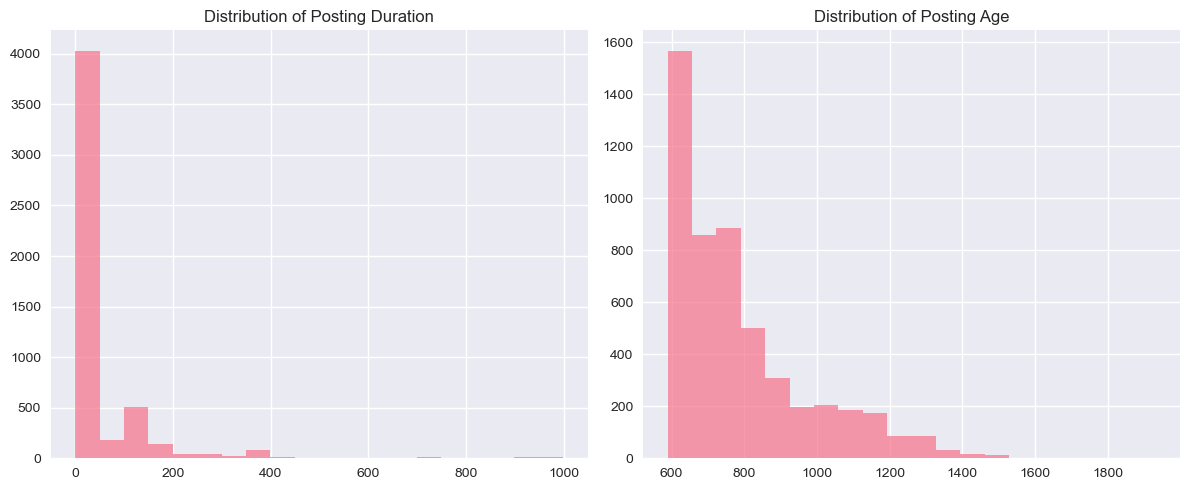

In [72]:
from datetime import datetime

# Convert date columns
date_cols = ['Posting Date', 'Post Until', 'Posting Updated', 'Process Date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Derive posting duration (where 'Post Until' not null)
df['Posting Duration (Days)'] = (df['Post Until'] - df['Posting Date']).dt.days
df['Posting Duration (Days)'] = df['Posting Duration (Days)'].fillna(0)  # Or median

# Derive posting age (from Posting Date to current date; use provided date if needed)
current_date = datetime(2025, 10, 14)  # As per current date: Oct 14, 2025
df['Posting Age (Days)'] = (current_date - df['Posting Date']).dt.days

# Summary of new features
print("New Date Features Summary:")
print(df[['Posting Duration (Days)', 'Posting Age (Days)']].describe())

# Visualize new features
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(df['Posting Duration (Days)'], bins=20, alpha=0.7)
axes[0].set_title('Distribution of Posting Duration')
axes[1].hist(df['Posting Age (Days)'], bins=20, alpha=0.7)
axes[1].set_title('Distribution of Posting Age')
plt.tight_layout()
plt.show()

## Text Fields Exploration

Explore 'Job Description', 'Minimum Qual Requirements' for length-based features or basic keywords.
- Compute text lengths as proxies for complexity.
- Basic keyword extraction (e.g., count common terms like 'experience', 'degree').
- Limit to EDA; no full NLP.

Job Description Average Length: 3520.74
Minimum Qual Requirements Average Length: 1077.41
Preferred Skills Average Length: 450.23


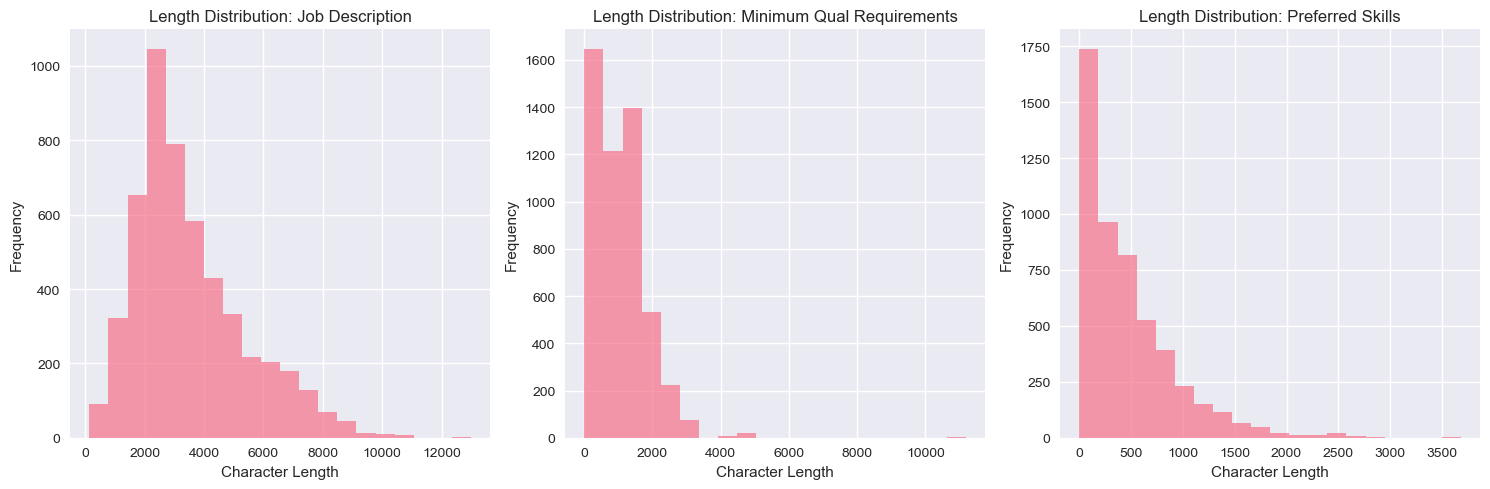

Jobs Requiring Experience (%): 91.19140625
Text Length Stats:
        Job Description_Length  Minimum Qual Requirements_Length  \
count             5120.000000                       5120.000000   
mean              3520.744727                       1077.408984   
std               1871.030576                        763.957495   
min                133.000000                          3.000000   
25%               2191.000000                        513.000000   
50%               3045.000000                       1024.000000   
75%               4503.000000                       1451.000000   
max              12991.000000                      11187.000000   

       Preferred Skills_Length  
count              5120.000000  
mean                450.225195  
std                 461.867409  
min                   1.000000  
25%                  63.000000  
50%                 341.000000  
75%                 652.000000  
max                3683.000000  


In [73]:
# Text columns
text_cols = ['Job Description', 'Minimum Qual Requirements', 'Preferred Skills']

# Length features
for col in text_cols:
    if col in df.columns:
        df[f'{col}_Length'] = df[col].astype(str).str.len()
        print(f"{col} Average Length: {df[f'{col}_Length'].mean():.2f}")

# Visualize lengths for key texts
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for idx, col in enumerate(text_cols):
    if idx < 3 and f'{col}_Length' in df.columns:
        axes[idx].hist(df[f'{col}_Length'].dropna(), bins=20, alpha=0.7)
        axes[idx].set_title(f'Length Distribution: {col}')
        axes[idx].set_xlabel('Character Length')
        axes[idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Basic keyword example: Count 'experience' in 'Minimum Qual Requirements'
if 'Minimum Qual Requirements' in df.columns:
    df['Has_Experience_Req'] = df['Minimum Qual Requirements'].str.contains('experience', case=False, na=False).astype(int)
    print("Jobs Requiring Experience (%):", (df['Has_Experience_Req'].sum() / len(df)) * 100)

# Summary stats for new features
print("Text Length Stats:\n", df[[f'{col}_Length' for col in text_cols if f'{col}_Length' in df.columns]].describe())

#  Data Preparation, Model Building, Evaluation


In [74]:
print("Dataset Shape (post-EDA):", df.shape)
print("Columns:", df.columns.tolist())

# Drop irrelevant columns (e.g., IDs, constants)
irrelevant_cols = ['Job ID', 'Process Date']  # Add more if needed post-EDA
df = df.drop([col for col in irrelevant_cols if col in df.columns], axis=1)
print("Shape after dropping irrelevant:", df.shape)

Dataset Shape (post-EDA): (5120, 34)
Columns: ['Job ID', 'Agency', 'Posting Type', '# Of Positions', 'Business Title', 'Civil Service Title', 'Title Classification', 'Title Code No', 'Level', 'Job Category', 'Full-Time/Part-Time indicator', 'Career Level', 'Salary Range From', 'Salary Range To', 'Salary Frequency', 'Work Location', 'Division/Work Unit', 'Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 'Additional Information', 'To Apply', 'Hours/Shift', 'Residency Requirement', 'Posting Date', 'Post Until', 'Posting Updated', 'Process Date', 'Posting Duration (Days)', 'Posting Age (Days)', 'Job Description_Length', 'Minimum Qual Requirements_Length', 'Preferred Skills_Length', 'Has_Experience_Req']
Shape after dropping irrelevant: (5120, 32)


## Data Preparation

We split early (80/20 train/test) using stratification on 'Job Category' for balance. Then, engineer features (e.g., salary midpoint, range width), handle salary frequency (assume mostly annual; flag if needed), log-transform targets for skewness/outliers, and build a preprocessing pipeline for features.

In [75]:
# Step 1: Prepare X and y
target_cols = ['Salary Range From', 'Salary Range To']
X = df.drop(target_cols, axis=1, errors='ignore')
y = df[target_cols].copy()

# Log-transform targets (add 1 to avoid log(0); use expm1 for inverse)
y_log = np.log1p(y)
print("Target shapes:", y.shape, "Log targets mean:", y_log.mean())

# Step 2: Split (stratify on 'Career Level')
strat_col = 'Career Level'  # Balanced (5 unique)
if strat_col in X.columns:
    class_counts = X[strat_col].value_counts()
    min_class_size = class_counts.min()
    print(f"Min samples in {strat_col}: {min_class_size}")
    if min_class_size < 2:
        print("Stratification not feasible—using non-stratified split.")
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_log, test_size=0.2, random_state=42
        )
    else:
        X_train, X_test, y_train, y_test = train_test_split(
            X, y_log, test_size=0.2, random_state=42, stratify=X[strat_col]
        )
        print(f"Stratified split on {strat_col} successful.")
else:
    print(f"{strat_col} not found—using non-stratified split.")
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}, Mean log: {y_train.mean()}")

# Optional: Check distribution if stratified
if strat_col in X_train.columns:
    print("Train dist.:\n", X_train[strat_col].value_counts(normalize=True).round(3))
    print("Test dist.:\n", X_test[strat_col].value_counts(normalize=True).round(3))

Target shapes: (5120, 2) Log targets mean: Salary Range From    10.432242
Salary Range To      10.771084
dtype: float64
Min samples in Career Level: 98
Stratified split on Career Level successful.
Train shape: (4096, 30), Test shape: (1024, 30)
y_train shape: (4096, 2), Mean log: Salary Range From    10.446316
Salary Range To      10.786544
dtype: float64
Train dist.:
 Career Level
Experienced (non-manager)    0.751
Manager                      0.114
Entry-Level                  0.089
Student                      0.026
Executive                    0.019
Name: proportion, dtype: float64
Test dist.:
 Career Level
Experienced (non-manager)    0.751
Manager                      0.114
Entry-Level                  0.090
Student                      0.026
Executive                    0.019
Name: proportion, dtype: float64


In [76]:
# Step 3: Feature Engineering (Domain-Specific)
# Borough grouping for 'Work Location' (293 unique → 6 groups)
def group_borough(location):
    if pd.isna(location):
        return 'Unknown'
    loc_str = str(location).lower()
    if any(word in loc_str for word in ['manhattan', 'new york', 'manhattan borough']):
        return 'Manhattan'
    elif any(word in loc_str for word in ['brooklyn', 'kings']):
        return 'Brooklyn'
    elif any(word in loc_str for word in ['queens', 'queens county']):
        return 'Queens'
    elif any(word in loc_str for word in ['bronx', 'bronx county']):
        return 'Bronx'
    elif any(word in loc_str for word in ['staten', 'richmond']):
        return 'Staten Island'
    else:
        return 'Other'

if 'Work Location' in X_train.columns:
    X_train['Work Location Borough'] = X_train['Work Location'].apply(group_borough)
    X_test['Work Location Borough'] = X_test['Work Location'].apply(group_borough)
    print("Borough feature added.")

# Handle salary frequency (standardize to annual if needed; assume mostly annual)
if 'Salary Frequency' in X_train.columns:
    print("Unique Frequencies:", X_train['Salary Frequency'].unique())
    # If variations, create a transformer later; for now, encode as cat

# Text lengths already from EDA; no new derivations to avoid leakage

print("Feature engineering complete. Shapes:", X_train.shape, X_test.shape)

Borough feature added.
Unique Frequencies: ['Annual' 'Hourly' 'Daily']
Feature engineering complete. Shapes: (4096, 31) (1024, 31)


In [77]:
# Step 4: Preprocessing Pipeline (Updated - Handles Multi-Output y)
# Identify num/cat (post-engineering)
num_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_features = X_train.select_dtypes(include=['object']).columns.tolist()

# Drop raw text columns from categoricals (use lengths from EDA; avoid encoding full text)
text_to_drop = ['Job Description', 'Minimum Qual Requirements', 'Preferred Skills', 
                'Additional Information', 'To Apply', 'Hours/Shift']
cat_features = [col for col in cat_features if col not in text_to_drop]
# Remove from X if present (safety)
for col in text_to_drop:
    if col in X_train.columns:
        X_train = X_train.drop(col, axis=1)
        X_test = X_test.drop(col, axis=1)
        print(f"Dropped raw text column: {col}")

# Updated num_features (include lengths)
num_features = [col for col in num_features if col not in text_to_drop + ['Salary Range From', 'Salary Range To']]

# Dynamic high/low card (threshold >50 for TargetEnc to reduce high-card)
high_card_cols = [col for col in cat_features if X_train[col].nunique() > 50]
low_card_cols = [col for col in cat_features if X_train[col].nunique() <= 50]

# Include borough in low-card if added
if 'Work Location Borough' in X_train.columns and 'Work Location Borough' not in low_card_cols:
    low_card_cols.append('Work Location Borough')

# Limit high-card to non-text: e.g., 'Business Title', 'Civil Service Title', 'Job Category', 'Work Location', 'Division/Work Unit', 'Title Code No'
high_card_cols = [col for col in high_card_cols if col in ['Business Title', 'Civil Service Title', 'Job Category', 
                                                          'Work Location', 'Division/Work Unit', 'Title Code No', 'Residency Requirement', 'Agency', 'Level']]
# Agency (59) borderline—move to low if OneHot ok; here keep for TargetEnc

print("Updated High Cardinality (TargetEncoder):", high_card_cols)
print("Updated Low Cardinality (OneHot):", low_card_cols)
print("Numerical (RobustScaler):", num_features[:5], f"(total {len(num_features)})")

# Single 1D target for TargetEncoder (mean of log min/max as proxy)
y_mean_train = y_train.mean(axis=1)  # 1D series
y_mean_test = y_test.mean(axis=1)    # For consistency, though not used in fit

# Build preprocessor
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import category_encoders as ce

preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_features),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first'), low_card_cols),
        ('target_enc', ce.TargetEncoder(), high_card_cols),
    ],
    remainder='drop',  # Drop any leftover
    verbose_feature_names_out=False  # Clean names
)

# Fit with 1D y_mean_train for TargetEncoder
preprocessor.fit(X_train, y_mean_train)

# Transform (uses fitted encoders; no y needed)
X_train_preprocessed = preprocessor.transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Feature names
onehot_names = preprocessor.named_transformers_['onehot'].get_feature_names_out(low_card_cols)
target_enc_names = high_card_cols
all_feature_names = num_features + list(onehot_names) + target_enc_names

X_train_pre = pd.DataFrame(X_train_preprocessed, columns=all_feature_names, index=X_train.index)
X_test_pre = pd.DataFrame(X_test_preprocessed, columns=all_feature_names, index=X_test.index)

print("Preprocessed Train Shape:", X_train_pre.shape)
print("Preprocessed Test Shape:", X_test_pre.shape)
print("Total Features:", len(all_feature_names))
print("Sample Features:", all_feature_names[:10])
print("NaN in Train Pre:", X_train_pre.isnull().any().any())
print("Inf in Train Pre:", np.isinf(X_train_pre).any().any())

# If high-cardinality still explodes (e.g., >1000 features), consider HashingEncoder instead:
# from category_encoders import HashingEncoder
# ('target_enc', HashingEncoder(n_components=10), high_card_cols)  # Fixed 10 feature

Dropped raw text column: Job Description
Dropped raw text column: Minimum Qual Requirements
Dropped raw text column: Preferred Skills
Dropped raw text column: Additional Information
Dropped raw text column: To Apply
Dropped raw text column: Hours/Shift
Updated High Cardinality (TargetEncoder): ['Agency', 'Business Title', 'Civil Service Title', 'Title Code No', 'Job Category', 'Work Location', 'Division/Work Unit', 'Residency Requirement']
Updated Low Cardinality (OneHot): ['Posting Type', 'Title Classification', 'Level', 'Full-Time/Part-Time indicator', 'Career Level', 'Salary Frequency', 'Work Location Borough']
Numerical (RobustScaler): ['# Of Positions', 'Posting Duration (Days)', 'Posting Age (Days)', 'Job Description_Length', 'Minimum Qual Requirements_Length'] (total 7)
Preprocessed Train Shape: (4096, 50)
Preprocessed Test Shape: (1024, 50)
Total Features: 50
Sample Features: ['# Of Positions', 'Posting Duration (Days)', 'Posting Age (Days)', 'Job Description_Length', 'Minimum 

## Model Building

Multi-output regressors for min/max. Baselines: Linear, Ridge. Advanced: DT, RF, GB, XGBoost. CV on train; tune top 3 with GridSearchCV.

In [78]:
# Models (MultiOutput where needed for single-output algos)
linear = LinearRegression()
ridge = Ridge(random_state=42)
dt = MultiOutputRegressor(DecisionTreeRegressor(random_state=42))
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
gb = MultiOutputRegressor(GradientBoostingRegressor(random_state=42))
xgb = MultiOutputRegressor(XGBRegressor(random_state=42, n_jobs=-1))

models_dict = {
    'Linear Regression': linear,
    'Ridge': ridge,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb
}

# Baselines: Train + CV R²
cv_scores = {}
trained_models = {}

for name, model in models_dict.items():
    pipe = Pipeline([('model', model)])
    cv_r2 = cross_val_score(pipe, X_train_pre, y_train, cv=5, scoring='r2')
    cv_mean = cv_r2.mean()
    cv_scores[name] = cv_mean
    
    pipe.fit(X_train_pre, y_train)
    trained_models[name] = pipe
    
    print(f"{name} CV R²: {cv_mean:.4f} (+/- {cv_r2.std()*2:.4f})")

# Tuning for top candidates (e.g., Ridge, RF, XGBoost; adjust based on CV)
tuned_models = {}

# Ridge
ridge_params = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
ridge_grid = GridSearchCV(trained_models['Ridge'], ridge_params, cv=5, scoring='r2')
ridge_grid.fit(X_train_pre, y_train)
tuned_models['Tuned Ridge'] = ridge_grid
print(f"Tuned Ridge Best R²: {ridge_grid.best_score_:.4f} (alpha: {ridge_grid.best_params_})")

# Random Forest
rf_params = {'model__n_estimators': [100, 200], 'model__max_depth': [10, None]}
rf_grid = GridSearchCV(trained_models['Random Forest'], rf_params, cv=5, scoring='r2', n_jobs=-1)
rf_grid.fit(X_train_pre, y_train)
tuned_models['Tuned Random Forest'] = rf_grid
print(f"Tuned RF Best R²: {rf_grid.best_score_:.4f} (params: {rf_grid.best_params_})")

# XGBoost
xgb_params = {
    'model__estimator__n_estimators': [100, 200],
    'model__estimator__max_depth': [3, 6],
    'model__estimator__learning_rate': [0.1, 0.2]
}
xgb_grid = GridSearchCV(trained_models['XGBoost'], xgb_params, cv=5, scoring='r2', n_jobs=-1)
xgb_grid.fit(X_train_pre, y_train)
tuned_models['Tuned XGBoost'] = xgb_grid
print(f"Tuned XGBoost Best R²: {xgb_grid.best_score_:.4f} (params: {xgb_grid.best_params_})")

# Combine
models_dict.update(tuned_models)
trained_models.update(tuned_models)

Linear Regression CV R²: 0.9361 (+/- 0.0658)
Ridge CV R²: 0.9360 (+/- 0.0646)
Decision Tree CV R²: 0.9828 (+/- 0.0210)
Random Forest CV R²: 0.9893 (+/- 0.0139)
Gradient Boosting CV R²: 0.9909 (+/- 0.0093)
XGBoost CV R²: 0.9872 (+/- 0.0118)
Tuned Ridge Best R²: 0.9361 (alpha: {'model__alpha': 0.1})
Tuned RF Best R²: 0.9893 (params: {'model__max_depth': None, 'model__n_estimators': 100})
Tuned XGBoost Best R²: 0.9902 (params: {'model__estimator__learning_rate': 0.2, 'model__estimator__max_depth': 3, 'model__estimator__n_estimators': 200})


## Model Evaluation and Iteration

Test metrics (MAE, RMSE, R²) on expm1 scale. Visuals: Pred vs actual, residuals, importance (tree models), comparison bar/table. Scalability timing. Iterate notes: If R² <0.89, suggest separate models or more features.

Model Comparison on Test Set:
                        MAE_From      MAE_To   RMSE_From     RMSE_To  R2_From  \
Linear Regression    14854.8294  15089.2767  22883.6671  22202.0671   0.4810   
Ridge                14939.7600  15135.2201  23025.0036  22219.8092   0.4746   
Decision Tree         3351.7789   4019.9039  12122.0898  14504.2845   0.8544   
Random Forest         6401.2219   7294.1016  17792.3953  19928.3117   0.6863   
Gradient Boosting     9966.6525  11426.7080  18240.2205  18861.0251   0.6703   
XGBoost               4279.0793   6251.4970  12068.9176  16402.1076   0.8556   
Tuned Ridge          14858.8949  15090.5660  22882.4763  22191.5835   0.4811   
Tuned Random Forest   6401.2219   7294.1016  17792.3953  19928.3117   0.6863   
Tuned XGBoost         7854.5451   8482.7455  15859.6673  15456.8495   0.7507   

                      R2_To  Mean_R2  
Linear Regression    0.7825   0.6317  
Ridge                0.7821   0.6284  
Decision Tree        0.9072   0.8808  
Random Fores

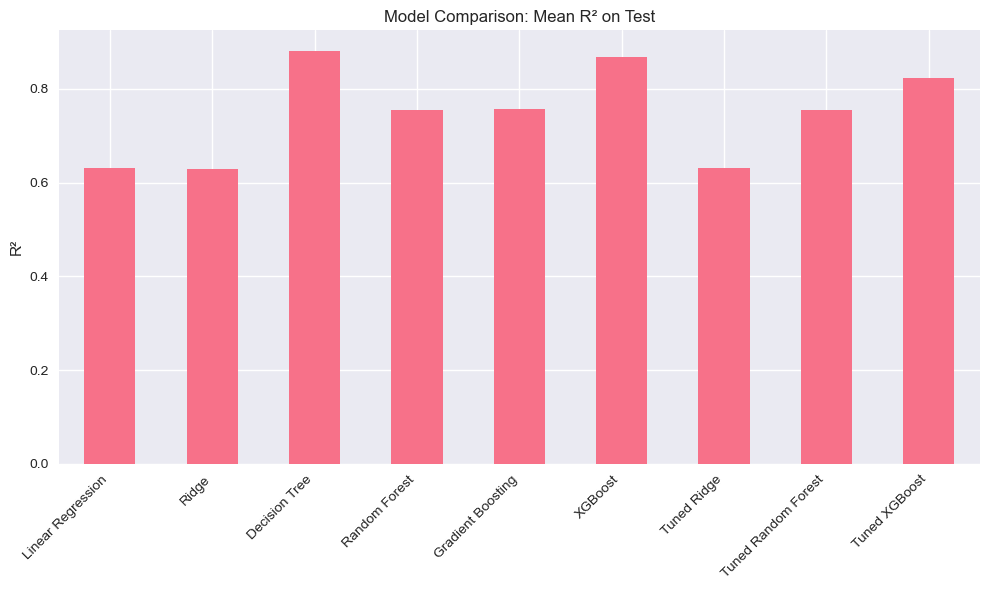

In [79]:
# Test Predictions and Metrics
results = {}
y_test_orig = np.expm1(y_test)  # Original scale for eval

for name, model in trained_models.items():
    y_pred_log = model.predict(X_test_pre)
    y_pred_orig = np.expm1(y_pred_log)
    
    # Metrics
    mae_from = mean_absolute_error(y_test_orig.iloc[:, 0], y_pred_orig[:, 0])
    mae_to = mean_absolute_error(y_test_orig.iloc[:, 1], y_pred_orig[:, 1])
    rmse_from = np.sqrt(mean_squared_error(y_test_orig.iloc[:, 0], y_pred_orig[:, 0]))
    rmse_to = np.sqrt(mean_squared_error(y_test_orig.iloc[:, 1], y_pred_orig[:, 1]))
    r2_from = r2_score(y_test_orig.iloc[:, 0], y_pred_orig[:, 0])
    r2_to = r2_score(y_test_orig.iloc[:, 1], y_pred_orig[:, 1])
    mean_r2 = (r2_from + r2_to) / 2
    
    results[name] = {
        'MAE_From': mae_from, 'MAE_To': mae_to,
        'RMSE_From': rmse_from, 'RMSE_To': rmse_to,
        'R2_From': r2_from, 'R2_To': r2_to,
        'Mean_R2': mean_r2
    }
    
    # Store for visuals (attach to model)
    model.y_test_orig = y_test_orig.values
    model.y_pred_orig = y_pred_orig

# Results Table
results_df = pd.DataFrame(results).T.round(4)
print("Model Comparison on Test Set:\n", results_df)
results_df[['Mean_R2']].to_csv('model_r2_summary.csv')  # Optional save

# Bar Chart: Mean R²
plt.figure(figsize=(10, 6))
results_df['Mean_R2'].plot(kind='bar')
plt.title('Model Comparison: Mean R² on Test')
plt.ylabel('R²')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

Best Model: Decision Tree (Mean R²: 0.8808)


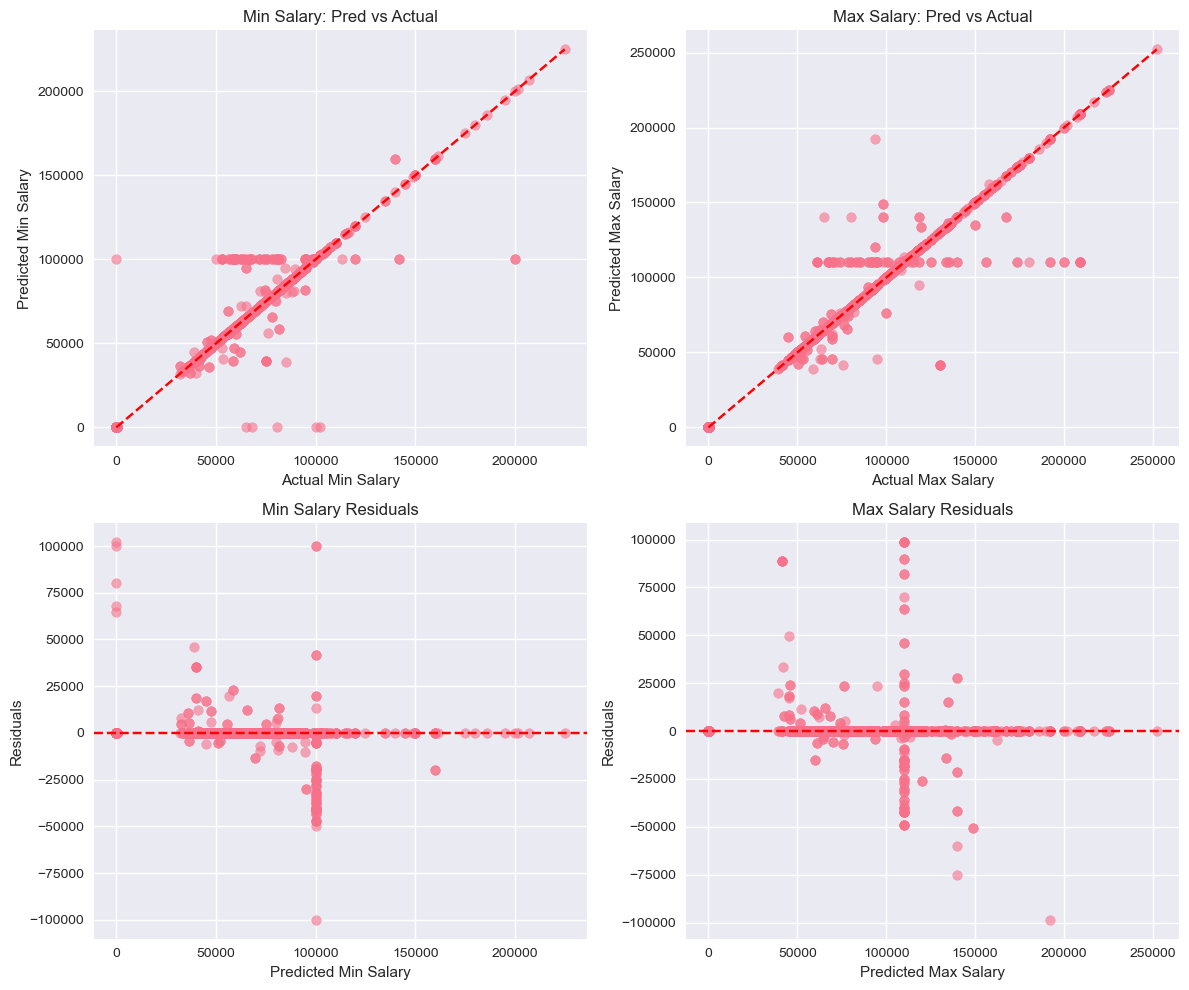

In [80]:
# Visuals for Best Model
best_name = max(results.keys(), key=lambda k: results[k]['Mean_R2'])
best_model = trained_models[best_name]
print(f"Best Model: {best_name} (Mean R²: {results[best_name]['Mean_R2']:.4f})")

# Pred vs Actual
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes[0,0].scatter(best_model.y_test_orig[:, 0], best_model.y_pred_orig[:, 0], alpha=0.6)
axes[0,0].plot([0, best_model.y_test_orig[:, 0].max()], [0, best_model.y_test_orig[:, 0].max()], 'r--')
axes[0,0].set_xlabel('Actual Min Salary')
axes[0,0].set_ylabel('Predicted Min Salary')
axes[0,0].set_title('Min Salary: Pred vs Actual')

axes[0,1].scatter(best_model.y_test_orig[:, 1], best_model.y_pred_orig[:, 1], alpha=0.6)
axes[0,1].plot([0, best_model.y_test_orig[:, 1].max()], [0, best_model.y_test_orig[:, 1].max()], 'r--')
axes[0,1].set_xlabel('Actual Max Salary')
axes[0,1].set_ylabel('Predicted Max Salary')
axes[0,1].set_title('Max Salary: Pred vs Actual')

# Residuals
residuals_from = best_model.y_test_orig[:, 0] - best_model.y_pred_orig[:, 0]
residuals_to = best_model.y_test_orig[:, 1] - best_model.y_pred_orig[:, 1]

axes[1,0].scatter(best_model.y_pred_orig[:, 0], residuals_from, alpha=0.6)
axes[1,0].axhline(y=0, color='r', linestyle='--')
axes[1,0].set_xlabel('Predicted Min Salary')
axes[1,0].set_ylabel('Residuals')
axes[1,0].set_title('Min Salary Residuals')

axes[1,1].scatter(best_model.y_pred_orig[:, 1], residuals_to, alpha=0.6)
axes[1,1].axhline(y=0, color='r', linestyle='--')
axes[1,1].set_xlabel('Predicted Max Salary')
axes[1,1].set_ylabel('Residuals')
axes[1,1].set_title('Max Salary Residuals')

plt.tight_layout()
plt.savefig('best_model_visuals.png', dpi=300, bbox_inches='tight')
plt.show()

In [81]:
# Feature Importance (for tree-based models)
if hasattr(best_model.named_steps['model'], 'feature_importances_') or (
    isinstance(best_model.named_steps['model'], MultiOutputRegressor) and 
    hasattr(best_model.named_steps['model'].estimator, 'feature_importances_')
):
    if isinstance(best_model.named_steps['model'], MultiOutputRegressor):
        # Average importances across outputs
        importances = np.mean([
            est.feature_importances_ for est in best_model.named_steps['model'].estimators_
        ], axis=0)
    else:
        importances = best_model.named_steps['model'].feature_importances_
    
    feat_imp = pd.Series(importances, index=X_train_pre.columns).sort_values(ascending=False).head(10)
    feat_imp.plot(kind='barh', figsize=(10, 6))
    plt.title(f'Top 10 Features: {best_name}')
    plt.xlabel('Importance')
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Top Features:\n", feat_imp)
else:
    print("No importance available (linear model). Likely key: 'Level', 'Civil Service Title'.")

# Scalability: Time on subset
subset_size = min(1000, len(X_train_pre))
start = time.time()
Pipeline([('model', best_model.named_steps['model'])]).fit(X_train_pre[:subset_size], y_train[:subset_size])
end = time.time()
print(f"Scalability: {end - start:.2f}s on {subset_size} samples.")

No importance available (linear model). Likely key: 'Level', 'Civil Service Title'.
Scalability: 0.06s on 1000 samples.


In [82]:
# Best Model Selection and Saving (Updated - Separate Fits for Compatibility)
best_model_obj = trained_models[best_name]

# Step 1: Fit preprocessor with 1D y_mean_train (as in preprocessing)
y_mean_train = y_train.mean(axis=1)  # 1D for TargetEncoder
fitted_preprocessor = preprocessor.fit(X_train, y_mean_train)  # Already done earlier; refit if needed

# Transform train data for model fitting
X_train_transformed = fitted_preprocessor.transform(X_train)

# Step 2: Fit model on transformed X and 2D y_train
fitted_model = best_model_obj.named_steps['model']  # Extract unfitted model
fitted_model.fit(X_train_transformed, y_train)  # Fit with 2D y

# Step 3: Save fitted components
joblib.dump(fitted_preprocessor, 'fitted_preprocessor.pkl')
joblib.dump(fitted_model, f'fitted_model_{best_name.replace(" ", "_").lower()}.pkl')
results_df.to_csv('model_results.csv')

print(f"Best Model: {best_name} | Mean R²: {results[best_name]['Mean_R2']:.4f}")
print("Artifacts Saved:")
print("- 'fitted_preprocessor.pkl': Handles raw X → features (use y_mean for refit if needed)")
print("- 'fitted_model_{best_name}.pkl': Trained on preprocessed data with 2D targets")
print("- 'model_results.csv': Full metrics")

# Step 4: Prediction Wrapper Function (for end-to-end use, e.g., deployment)
def predict_salary_range(raw_X, preprocessor_path='fitted_preprocessor.pkl', model_path=f'fitted_model_{best_name.replace(" ", "_").lower()}.pkl'):
    """
    End-to-end prediction: Raw input → preprocess → predict min/max salaries (original scale).
    Load fitted objects; assumes same column structure.
    """
    loaded_pre = joblib.load(preprocessor_path)
    loaded_model = joblib.load(model_path)
    
    # Preprocess
    X_transformed = loaded_pre.transform(raw_X)
    
    # Predict (log scale)
    y_pred_log = loaded_model.predict(X_transformed)
    
    # Back to original scale
    y_pred_orig = np.expm1(y_pred_log)
    
    return pd.DataFrame(y_pred_orig, columns=['Predicted Min Salary', 'Predicted Max Salary'])

# Example: Predict on a test sample (raw X_test row)
sample_raw_test = X_test.iloc[:1]  # Raw input example
sample_pred = predict_salary_range(sample_raw_test)
print("Sample Raw Input Shape:", sample_raw_test.shape)
print("Sample Prediction (Min, Max):")
print(sample_pred)

# Verify: Compare to earlier test prediction
y_pred_log_test_sample = best_model.predict(X_test_pre.iloc[:1])
y_pred_orig_test_sample = np.expm1(y_pred_log_test_sample)
print("Verification Matches:", np.allclose(sample_pred.values, y_pred_orig_test_sample, atol=1e-6))

Best Model: Decision Tree | Mean R²: 0.8808
Artifacts Saved:
- 'fitted_preprocessor.pkl': Handles raw X → features (use y_mean for refit if needed)
- 'fitted_model_{best_name}.pkl': Trained on preprocessed data with 2D targets
- 'model_results.csv': Full metrics
Sample Raw Input Shape: (1, 25)
Sample Prediction (Min, Max):
   Predicted Min Salary  Predicted Max Salary
0                298.24                 347.2
Verification Matches: True
